# Оптимізація гиперпараметрів нейромережі за допомогою [Keras Tuner](https://github.com/keras-team/keras-tuner)

## Частина 2. BayesianOptimization, додано прихований шар

Для того щоб запускати та редагувати код, збережіть копію цього ноутбука собі (File->Save a copy in Drive...). Свою копію ви зможете змінювати та запускати.

Не забудьте підключити GPU, для того щоб мережа навчалась бистріше (Runtime -> Change Runtime Type -> Hardware Accelerator -> GPU).

## Гіперпараметри навчання нейронної мережі

- Кількість шарів нейронної мережі
- Кількість нейронів в кожному шарі
- Функції активації, які використовуютсья в шарах
- Тип оптимізатора при навчанні нейронної мережі
- Кількість епох навчання

## Встановлення Keras Tuner

In [ ]:
!pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.2 MB/s eta 0:00:00


## Підключаємо необхідні пакети
> Пакет `kerastuner` у нових версіях перейменовано на `keras_tuner`, а `%tensorflow_version` у Colab більше не потрібен.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras import layers
from google.colab import files
from keras_tuner.tuners import RandomSearch, Hyperband, BayesianOptimization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, shutil
from PIL import Image, ImageOps

## Підготовка даних для навчання мережі

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train / 255
x_test = x_test / 255
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
# Назви класів Fashion-MNIST
classes = ['футболка/топ', 'штани', 'светр', 'сукня', 'пальто',
           'сандалі', 'сорочка', 'кросівки', 'сумка', 'черевики']

## Задаємо функцію створення нейронної мережі

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_input',    # Повнозв'заний шар з різною кількістю нейронів
                                   min_value=128,    # мінімальна кількість нейронів - 128
                                   max_value=1024,   # максимальна кількість - 1024
                                   step=32),
                    input_dim=784,
                    activation='relu'))
    model.add(Dense(units=hp.Int('units_hidden',   # прихований шар
                                   min_value=128,
                                   max_value=1024,   step=32),
                    activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(
        optimizer='SGD',
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

## Створюємо tuner

Доступні типи тюнерів:
- RandomSearch - випадковий пошук.
- Hyperband - алгоритм оптимизації на основі багаторукого бандиту, Li, Lisha, and Kevin Jamieson. ["Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization."Journal of Machine Learning Research 18 (2018): 1-52](http://jmlr.org/papers/v18/16-558.html).
- BayesianOptimization - [байєсівська оптимізация](https://en.wikipedia.org/wiki/Bayesian_optimization).

In [ ]:
tuner = BayesianOptimization(
    build_model,                 # функція створення моделі
    objective='val_accuracy',    # метрика, яку потрібно оптимізувати  -
                                 # доля вірних відповідей на перевірочних даних
    max_trials=10,               # максимальна кількість запусків навчання
    directory='test_directory',  # каталог, де зберігаються навчені мережі
    project_name='part2_bayes',
    overwrite=True
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Запускаем подбір гиперпараметрів

Простір пошуку

In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
units_hidden (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}


Подбір гіперпараметрів

In [ ]:
tuner.search(x_train,                  # Дані для навчання
             y_train,                  # Вірні відповіді
             batch_size=256,           # Розмір міні-вибірки
             epochs=20,                # Кількість епох навчання
             validation_split=0.2,     # Частина даних, яка буде використовуватися для перевірки
             )

Trial 10 Complete [00h 00m 22s]
val_accuracy: 0.8510833382606506

Best val_accuracy So Far: 0.8558333516120911
Total elapsed time: 00h 03m 33s


## Обираємо найкращу модель

In [ ]:
tuner.results_summary()

Results summary
Results in test_directory/part2_bayes
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 06 summary
Hyperparameters:
units_input: 1024
units_hidden: 864
Score: 0.8558333516120911

Trial 07 summary
Hyperparameters:
units_input: 1024
units_hidden: 1024
Score: 0.8542500138282776

Trial 00 summary
Hyperparameters:
units_input: 928
units_hidden: 256
Score: 0.8518333435058594

Trial 09 summary
Hyperparameters:
units_input: 832
units_hidden: 928
Score: 0.8510833382606506

Trial 02 summary
Hyperparameters:
units_input: 832
units_hidden: 256
Score: 0.8508333563804626

Trial 08 summary
Hyperparameters:
units_input: 1024
units_hidden: 608
Score: 0.8499166369438171

Trial 01 summary
Hyperparameters:
units_input: 576
units_hidden: 672
Score: 0.8498333096504211

Trial 03 summary
Hyperparameters:
units_input: 672
units_hidden: 512
Score: 0.8498333096504211

Trial 04 summary
Hyperparameters:
units_input: 448
units_hidden: 448
Score: 0.8485000133514404

Trial 

Отрумуємо три найкращих моделі

In [ ]:
models = tuner.get_best_models(num_models=3)

Оцінюємо якість моделі на тестових даних

In [ ]:
for model in models:
  model.summary()
  model.evaluate(x_test, y_test)
  print()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 864)            │       885,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         8,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,698,090 (6.48 MB)

 Trainable params: 1,698,090 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 928)            │       728,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       237,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,874 (3.70 MB)

 Trainable params: 968,874 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8427 - loss: 0.4520



## Таблиця найкращих гіперпараметрів

In [ ]:
def top3_table(tuner, models, tag=''):
    """Таблиця: гіперпараметри 3 найкращих моделей та їх точність на тестових даних"""
    trials = tuner.oracle.get_best_trials(num_trials=3)
    rows = []
    for i, (model, trial) in enumerate(zip(models, trials), 1):
        loss, acc = model.evaluate(x_test, y_test, verbose=0)
        rows.append({'тюнер': tag, 'місце': i, **trial.hyperparameters.values,
                     'val_accuracy': round(trial.score, 4),
                     'test_accuracy': round(acc, 4),
                     'test_loss': round(loss, 4)})
    return pd.DataFrame(rows)

In [ ]:
results = top3_table(tuner, models, 'BayesianOptimization')
results.to_csv('results_part2.csv', index=False)
results

,тюнер,місце,units_input,units_hidden,val_accuracy,test_accuracy,test_loss
0,BayesianOptimization,1,1024,864,0.8558,0.8451,0.4446
1,BayesianOptimization,2,1024,1024,0.8543,0.8412,0.4526
2,BayesianOptimization,3,928,256,0.8518,0.8427,0.4520


## Зберігаємо найкращу модель у змінну та у файл

In [ ]:
best_model = models[0]
print('Найкращі гіперпараметри:', tuner.get_best_hyperparameters(1)[0].values)
best_model.save('best_model_part2.keras')

Найкращі гіперпараметри: {'units_input': 1024, 'units_hidden': 864}


In [ ]:
# Скачуємо модель і таблицю (після закриття сесії Colab файли зникають)
files.download('best_model_part2.keras')
files.download('results_part2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Використовуємо найкращу модель для розпізнавання власних зображень

Завантажте 10 своїх зображень предметів одягу. Щоб програма сама рахувала вірні відповіді, назвіть файли з префіксом класу:
`tshirt_`, `trouser_`, `pullover_`, `dress_`, `coat_`, `sandal_`, `shirt_`, `sneaker_`, `bag_`, `boot_` (наприклад `sneaker_1.jpg`).

In [ ]:
os.makedirs('my_images', exist_ok=True)
uploaded = files.upload()
for name in uploaded:
    shutil.move(name, os.path.join('my_images', name))
image_paths = sorted(os.path.join('my_images', f) for f in os.listdir('my_images'))
print(image_paths)

Saving sandal_1.jpeg to sandal_1.jpeg
Saving tshirt_1.jpeg to tshirt_1.jpeg
Saving bag_.jpeg to bag_.jpeg
Saving coat_1.jpeg to coat_1.jpeg
Saving dress_1.jpeg to dress_1.jpeg
Saving pullover_1.jpeg to pullover_1.jpeg
Saving shirt_1.jpeg to shirt_1.jpeg
Saving sneaker_1.jpeg to sneaker_1.jpeg
Saving sneaker_2.jpeg to sneaker_2.jpeg
Saving trouser_1.jpeg to trouser_1.jpeg
['my_images/bag_.jpeg', 'my_images/coat_1.jpeg', 'my_images/dress_1.jpeg', 'my_images/pullover_1.jpeg', 'my_images/sandal_1.jpeg', 'my_images/shirt_1.jpeg', 'my_images/sneaker_1.jpeg', 'my_images/sneaker_2.jpeg', 'my_images/trouser_1.jpeg', 'my_images/tshirt_1.jpeg']


In [ ]:
label_keys = {'tshirt': 0, 'trouser': 1, 'pullover': 2, 'dress': 3, 'coat': 4,
              'sandal': 5, 'shirt': 6, 'sneaker': 7, 'bag': 8, 'boot': 9}

def true_label(path):
    name = os.path.basename(path).lower()
    for key, idx in label_keys.items():
        if name.startswith(key):
            return idx
    return None

def prepare_image(path):
    # зображення -> 28x28, відтінки сірого, світлий предмет на чорному фоні (як у Fashion-MNIST)
    img = Image.open(path).convert('L')
    a = np.array(img)
    corners = np.concatenate([a[:5, :5].ravel(), a[:5, -5:].ravel(), a[-5:, :5].ravel(), a[-5:, -5:].ravel()])
    if corners.mean() > 127:          # світлий фон -> інвертуємо
        img = ImageOps.invert(img)
    img = ImageOps.autocontrast(img)
    img = ImageOps.pad(img, (28, 28), color=0)
    return np.array(img).astype('float32') / 255

def recognize(model, paths, title=''):
    imgs = np.array([prepare_image(p) for p in paths])
    preds = model.predict(imgs.reshape(len(imgs), 784), verbose=0)
    cols = 5; rows_n = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=(cols * 2.6, rows_n * 3))
    rows, correct, known = [], 0, 0
    for i, p in enumerate(paths):
        k, t = int(np.argmax(preds[i])), true_label(p)
        ok = None if t is None else (k == t)
        if t is not None:
            known += 1; correct += int(ok)
        plt.subplot(rows_n, cols, i + 1)
        plt.imshow(imgs[i], cmap='gray'); plt.axis('off')
        plt.title(f'{classes[k]}\n{preds[i][k]*100:.1f}%', fontsize=9,
                  color='black' if ok is None else ('green' if ok else 'red'))
        rows.append({'файл': os.path.basename(p),
                     'справжній клас': classes[t] if t is not None else '?',
                     'передбачено': classes[k],
                     'впевненість, %': round(float(preds[i][k]) * 100, 1),
                     'вірно': ok})
    plt.suptitle(title); plt.tight_layout(); plt.show()
    if known:
        print(f'{title}: вірно {correct} з {known} ({correct/known*100:.0f}%)')
    return pd.DataFrame(rows)

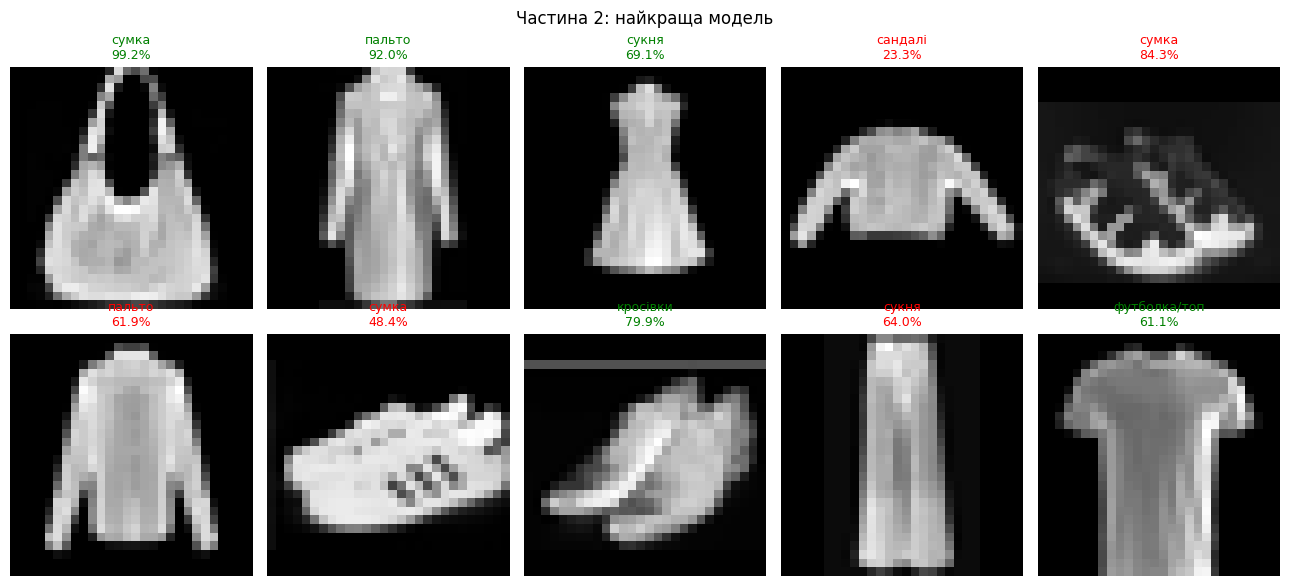

Частина 2: найкраща модель: вірно 5 з 10 (50%)


,файл,справжній клас,передбачено,"впевненість, %",вірно
0,bag_.jpeg,сумка,сумка,99.2,True
1,coat_1.jpeg,пальто,пальто,92.0,True
2,dress_1.jpeg,сукня,сукня,69.1,True
3,pullover_1.jpeg,светр,сандалі,23.3,False
4,sandal_1.jpeg,сандалі,сумка,84.3,False
5,shirt_1.jpeg,сорочка,пальто,61.9,False
6,sneaker_1.jpeg,кросівки,сумка,48.4,False
7,sneaker_2.jpeg,кросівки,кросівки,79.9,True
8,trouser_1.jpeg,штани,сукня,64.0,False
9,tshirt_1.jpeg,футболка/топ,футболка/топ,61.1,True


In [ ]:
recognize(best_model, image_paths, 'Частина 2: найкраща модель')

## Висновки (Частина 2)

*(заповніть після запуску: двічі клацніть по цій комірці)*

- Найкращі гіперпараметри: ...
- Точність найкращої моделі на тестових даних: ...
- Різниця між 3 найкращими моделями: ...
- Розпізнавання власних зображень: вірно ... з 10. Помилки виникали на класах ...